In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os
from dotenv import load_dotenv
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import cosine_similarity
import json
import networkx as nx
from scipy import stats
from scipy.stats import chi2_contingency
load_dotenv()

True

In [4]:
error_per_kc=pd.read_csv(os.getenv('error_per_kc'))
q_metadata=pd.read_csv(os.getenv('QUESTION_METADATA_PATH'))
responses=pd.read_csv(os.getenv('RESPONSES_PROCESSED_PATH'))
q_differentiation=pd.read_csv(os.getenv('differentiation_cumulative'))
learning_deltas=pd.read_csv(os.getenv('chronological_delta_path'))
kc_metadata=pd.read_csv(os.getenv('KC_METADATA_PATH'))
emb_path=os.getenv('KC_EMB_PATH')
with open(emb_path, 'r') as f:
    kc_embeddings = json.load(f)

emb_path=os.getenv('QUESTION_EMB')
with open(emb_path, 'r') as f:
    q_embeddings = json.load(f)


### Question Error grouping based on KCs

In [ ]:
#drop the solved column
data=error_per_kc.drop(columns=['solved'])
pivot=error_per_kc.pivot(
    index='uid',
    columns='concepts',
    values='error'
).fillna(0)
scaler=StandardScaler()
scaled_kc_error=scaler.fit_transform(pivot)

In [4]:
# Calculate correlation between every pair of KCs
kc_correlation = pivot.corr()

In [ ]:
threshold=0.4
high_corr_pairs = []
for i in range(len(kc_correlation.columns)):
    for j in range(i+1, len(kc_correlation.columns)):
        corr = kc_correlation.iloc[i, j]
        if corr > threshold:
            high_corr_pairs.append({
                'kc1': kc_correlation.columns[i],
                'kc2': kc_correlation.columns[j],
                'correlation': corr
            })

high_corr_df = pd.DataFrame(high_corr_pairs)
print(f"Found {len(high_corr_df)} KC pairs with correlation > {threshold}")
print(high_corr_df)
high_corr_df.to_csv('high_correlation_kc_pairs.csv', index=False)

Found 212 KC pairs with correlation > 0.4
     kc1  kc2  correlation
0     11   17     0.616459
1     11   66     0.459699
2     11  326     0.562701
3     17  326     0.713933
4     18  165     0.533574
..   ...  ...          ...
207  844  845     0.408178
208  844  846     0.707033
209  848  864     0.707082
210  849  864     0.499896
211  858  859     1.000000

[212 rows x 3 columns]


In [6]:
G = nx.Graph()
for _, row in high_corr_df.iterrows():
    G.add_edge(row['kc1'], row['kc2'], weight=row['correlation'])

# Find connected components (clusters of KCs that are highly correlated)
components = list(nx.connected_components(G))
print(f"\nFound {len(components)} connected components of KCs")
attempts_lookup = dict(zip(kc_metadata['kc_id'], kc_metadata['attempted']))

cluster_data = []
for i, comp in enumerate(components):
    if len(comp) >= 2:
        kc_list = sorted([int(kc) for kc in comp])
        attempts_list = [attempts_lookup.get(kc, 0) for kc in kc_list]
        
        # Get average correlation
        subgraph = G.subgraph(comp)
        weights = [data['weight'] for _, _, data in subgraph.edges(data=True)]
        avg_corr = sum(weights) / len(weights) if weights else 0
        
        cluster_data.append({
            'cluster_id': i,
            'kcs': kc_list,
            'n_kcs': len(kc_list),
            'avg_correlation': avg_corr,
            'attempts': attempts_list,
            'min_attempts': min(attempts_list),
            'max_attempts': max(attempts_list),
            'avg_attempts': sum(attempts_list) / len(attempts_list)
        })

cluster_df = pd.DataFrame(cluster_data)
cluster_df.to_csv('kc_error_clusters.csv', index=False)

print(cluster_df.head(10))


Found 90 connected components of KCs
   cluster_id                kcs  n_kcs  avg_correlation  \
0           0  [11, 17, 66, 326]      4         0.588198   
1           1          [18, 165]      2         0.533574   
2           2     [20, 579, 645]      3         0.495896   
3           3          [29, 333]      2         0.610706   
4           4      [32, 33, 252]      3         0.452821   
5           5          [47, 585]      2         0.426428   
6           6           [49, 50]      2         0.986720   
7           7          [71, 484]      2         0.923219   
8           8          [79, 275]      2         0.405471   
9           9          [88, 227]      2         0.418036   

                             attempts  min_attempts  max_attempts  \
0  [15176.0, 7237.0, 18585.0, 5605.0]        5605.0       18585.0   
1                 [120791.0, 22256.0]       22256.0      120791.0   
2              [6842.0, 746.0, 843.0]         746.0        6842.0   
3                     [47

In [13]:
#how many kcs cluster together
print(f"\nNumber of KCs that cluster together: {sum(cluster_df['n_kcs'])} out of {len(kc_metadata[kc_metadata['attempted'] >= 1])} total KCs")

#avg attempts of a kc in the dataset
print(f"\nMedian attempts per KC in the dataset: {kc_metadata[kc_metadata['attempted'] >= 1]['attempted'].median()}")

#how many clusters have a good amount of attempts
min_attempts_threshold = 100
good_clusters = cluster_df[cluster_df['min_attempts'] >= min_attempts_threshold]
print(f"\nNumber of clusters with at least {min_attempts_threshold} attempts: {len(good_clusters)}")

#how many KCs are in the good clusters
good_kcs = sum(good_clusters['n_kcs'])
print(f"\nNumber of KCs in good clusters: {good_kcs} out of {len(kc_metadata[kc_metadata['attempted'] >= 1])} total KCs")


Number of KCs that cluster together: 252 out of 865 total KCs

Median attempts per KC in the dataset: 1097.0

Number of clusters with at least 100 attempts: 63

Number of KCs in good clusters: 173 out of 865 total KCs


average similarity of clusters: 0.7221652077349309
average similarity of filtered clusters: 0.7571400102230262
Baseline similarity (random 3 KCs): 0.6286565605206843


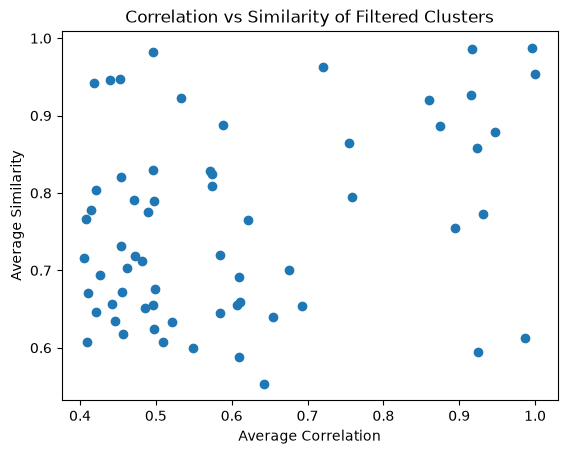

C:\Users\Hatem\AppData\Local\Temp\ipykernel_3780\3720338795.py:45: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(cluster_df_filtered['avg_similarity'], shade=True)


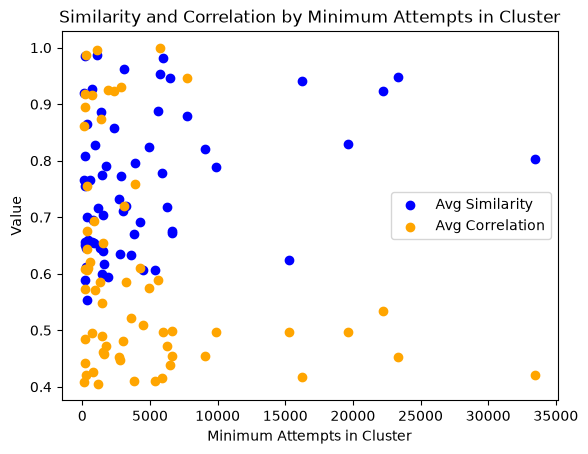

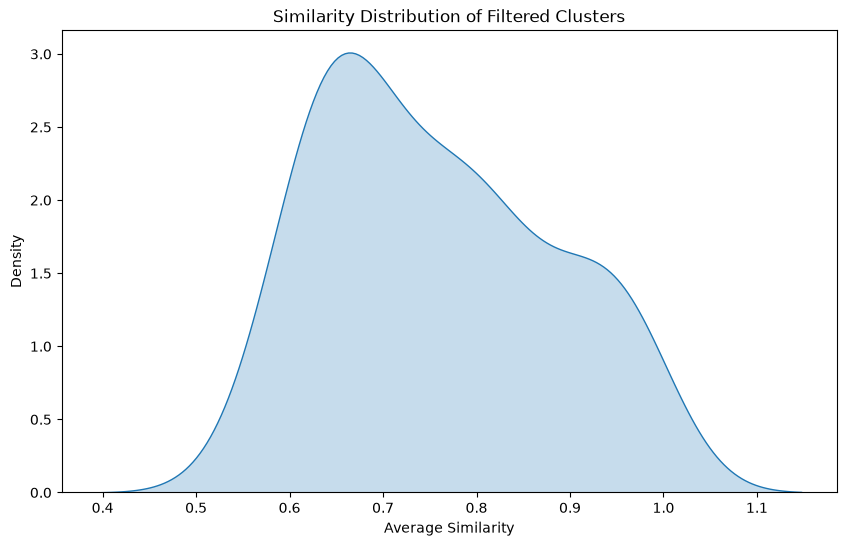

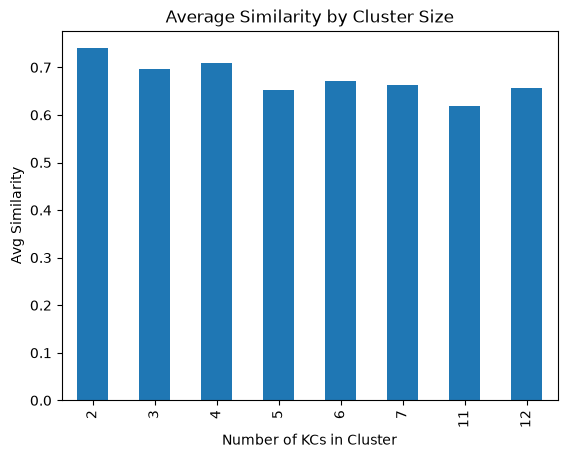


T-test: t=7.212, p=0.0000
Statistically significant: clusters are more similar than random


In [37]:
def compute_cluster_similarity(kc_list):
    # Get embeddings
    cluster_embeddings = np.array([kc_embeddings[kc] for kc in kc_list])
    
    # Compute cosine similarity
    sim_matrix = cosine_similarity(cluster_embeddings)
    upper_tri = np.triu_indices_from(sim_matrix, k=1)
    return sim_matrix[upper_tri].mean()

cluster_df['avg_similarity'] = cluster_df['kcs'].apply(compute_cluster_similarity)

print(f"average similarity of clusters: {cluster_df['avg_similarity'].mean()}")

#similarity in clusters with at least 100 attempts
cluster_df_filtered = cluster_df[cluster_df['min_attempts'] >= 100]
print(f"average similarity of filtered clusters: {cluster_df_filtered['avg_similarity'].mean()}")

n_random=800
random_sims=[]

for _ in range(n_random):
    random_kcs = np.random.choice(list(kc_embeddings.keys()), size=3, replace=False)
    random_sims.append(compute_cluster_similarity(random_kcs))

baseline_similarity = np.mean(random_sims)
print(f"Baseline similarity (random 3 KCs): {baseline_similarity}")

#plot correlation vs similarity for clusters with at least 100 attempts
plt.scatter(cluster_df_filtered['avg_correlation'], cluster_df_filtered['avg_similarity'])
plt.xlabel('Average Correlation')
plt.ylabel('Average Similarity')
plt.title('Correlation vs Similarity of Filtered Clusters')
plt.show()

#plot similarity and correlation by min_attempts
plt.scatter(cluster_df_filtered['min_attempts'], cluster_df_filtered['avg_similarity'], label='Avg Similarity', color='blue')
plt.scatter(cluster_df_filtered['min_attempts'], cluster_df_filtered['avg_correlation'], label='Avg Correlation', color='orange')
plt.xlabel('Minimum Attempts in Cluster')
plt.ylabel('Value')
plt.title('Similarity and Correlation by Minimum Attempts in Cluster')
plt.legend()

#similarity distribution kde for clusters with at least 100 attempts
plt.figure(figsize=(10, 6))
sns.kdeplot(cluster_df_filtered['avg_similarity'], shade=True)
plt.title('Similarity Distribution of Filtered Clusters')
plt.xlabel('Average Similarity')
plt.ylabel('Density')
plt.show()

# Does cluster size matter?
cluster_df.groupby('n_kcs')['avg_similarity'].mean().plot(kind='bar')
plt.title('Average Similarity by Cluster Size')
plt.xlabel('Number of KCs in Cluster')
plt.ylabel('Avg Similarity')
plt.show()

cluster_similarities=cluster_df['avg_similarity'].dropna()
t_stat, p_value = stats.ttest_1samp(cluster_similarities, baseline_similarity)

print(f"\nT-test: t={t_stat:.3f}, p={p_value:.4f}")
if p_value < 0.05:
    print("Statistically significant: clusters are more similar than random")
else:
    print("Not statistically significant")


### Improvement Grouping 

C:\Users\Hatem\AppData\Local\Temp\ipykernel_132\1522427862.py:11: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  general_improvement=df_sorted.groupby('uid').apply(


practice improvement
                uid  before_error   after_error  learning_delta  \
count  14453.000000  14453.000000  14453.000000    14453.000000   
mean    9014.853802      0.228979      0.211784       -0.017195   
std     5218.881455      0.135024      0.129097        0.044570   
min        0.000000      0.000851      0.002174       -0.241857   
25%     4503.000000      0.126969      0.115479       -0.042726   
50%     8998.000000      0.204441      0.186722       -0.015502   
75%    13540.000000      0.306549      0.282282        0.008362   
max    18064.000000      0.865132      0.875536        0.213765   

       improvement_rate  
count      14453.000000  
mean           0.768469  
std            0.124156  
min            0.123932  
25%            0.702602  
50%            0.793282  
75%            0.859438  
max            0.985356  
significant improvement rate 5482 vs 7618
         questions  before_error  after_error  learning_delta  \
count  7618.000000   6640.000000  

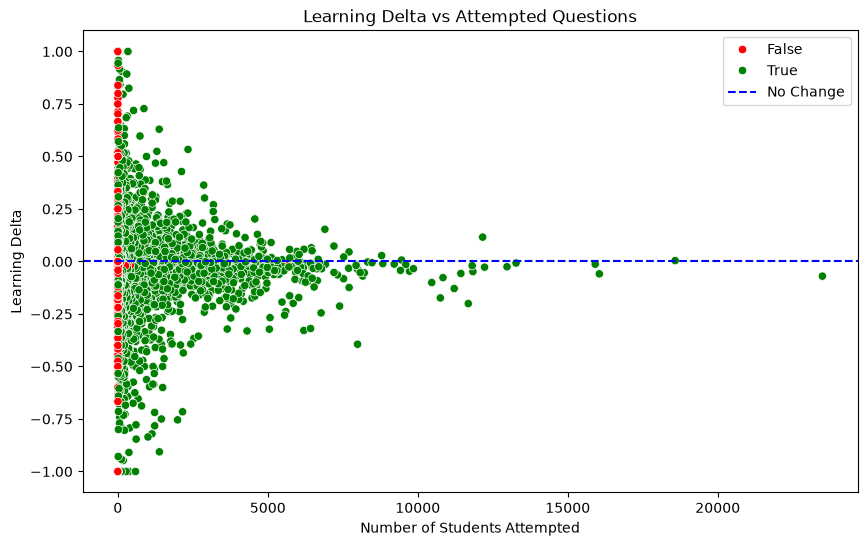

: 

In [ ]:
df_sorted = responses.sort_values(['uid', 'timestamps'])
df_sorted['error'] = 1 - df_sorted['responses']

#general improvement
df_sorted['prev_error'] = df_sorted.groupby('uid')['error'].transform(
    lambda x: x.expanding().mean().shift()
)
df_sorted['next_error'] = df_sorted.groupby('uid')['error'].shift(-1)

#aggregate
general_improvement=df_sorted.groupby('uid').apply(
    lambda group: pd.Series({
        'before_error': group['prev_error'].mean(),
        'after_error': group['next_error'].mean(),
        'learning_delta': group['next_error'].mean() - group['prev_error'].mean(),
        'improvement_rate': (group['next_error'] < group['prev_error']).mean()
    })
).reset_index()

improvement_mean=general_improvement['learning_delta'].mean()
improvement_std=general_improvement['learning_delta'].std()
improvement_rate=general_improvement['improvement_rate'].mean()
improvement_rate_std=general_improvement['improvement_rate'].std()

print(f"practice improvement\n{general_improvement.describe()}")


learning_deltas=pd.merge(
learning_deltas,q_metadata[['question_id','attempted']],
left_on='questions',right_on='question_id',
how='left'
)


def test_question_vs_baseline(question_delta, n_students, baseline_mean, baseline_std):
    if n_students < 3:
        return np.nan, np.nan
    
    # Standard error of the question's mean
    se = baseline_std / np.sqrt(n_students)
    
    # Z-score
    z_score = (question_delta - baseline_mean) / se
    
    # Two-tailed p-value
    p_value = 2 * (1 - stats.norm.cdf(abs(z_score)))
    
    return z_score, p_value

learning_deltas['z_score'] = np.nan
learning_deltas['p_value'] = np.nan
learning_deltas['significant'] = False

#test of significance on delta we are comparing two means of presumably normal distributions this is......
for idx, row in learning_deltas.iterrows():
    q_id=row['questions']
    q_delta=row['learning_delta']
    n_solved=row['attempted']

    if n_solved >=10:
        z_score, p_value = test_question_vs_baseline(q_delta, n_solved, improvement_mean, improvement_std)
        learning_deltas.loc[idx, 'z_score'] = z_score
        learning_deltas.loc[idx, 'p_value'] = p_value
        learning_deltas.loc[idx, 'significant'] = p_value < 0.05


print(f"significant improvement rate {len(learning_deltas[learning_deltas['significant']==True])} vs {len(learning_deltas)}")
print(learning_deltas.describe())

#plot learning_delta vs attempted
plt.figure(figsize=(10, 6))
sns.scatterplot(data=learning_deltas, x='attempted', y='learning_delta', hue='significant', palette={True: 'green', False: 'red'})
plt.axhline(0, color='blue', linestyle='--', label='No Change')
plt.title('Learning Delta vs Attempted Questions')
plt.xlabel('Number of Students Attempted')
plt.ylabel('Learning Delta')
plt.legend()
plt.show()

### Question error grouping based on textual features

In [4]:
q_features=['question_id','kc_ids','super_topic_ids','attempted','error_rate',
            'solution_complexity_x','solution_complexity_y',
            'question_length','num_variables',
            'num_sentences','num_clauses','relies_on_image',
            'vocabulary_richness','num_solutions',
            'solution_length','num_equations',
            'num_steps','solution_vocab','solution_relies_on_image',
            'has_multiple_methods']

text_metadata=q_metadata[q_features]

min_error=0.35
min_attempts=100
high_error=text_metadata[(text_metadata['error_rate']>min_error)&
                         (text_metadata['attempted']>min_attempts)].copy()

all_questions=text_metadata[text_metadata['attempted']>min_attempts].copy()


print("\n=== Textual Feature Comparison ===")
print(f"{'Feature':<25} {'All Questions':<15} {'High Error':<15} {'Difference':<15} {'p-value':<10}")
print("-" * 80)

for feature in ['question_length', 'num_variables', 'num_sentences', 'num_clauses', 
                'vocabulary_richness', 'num_solutions', 'solution_complexity_x', 
                'solution_complexity_y', 'solution_length', 'num_equations', 'num_steps']:
    
    all_mean = all_questions[feature].mean()
    high_mean = high_error[feature].mean()
    diff = high_mean - all_mean
    diff_pct = (diff / all_mean) * 100
    
    # T-test
    t_stat, p_val = stats.ttest_ind(all_questions[feature].dropna(), high_error[feature].dropna())
    
    print(f"{feature:<25} {all_mean:<15.2f} {high_mean:<15.2f} {diff:+.2f} ({diff_pct:+.1f}%) {p_val:.4f}")


=== Textual Feature Comparison ===
Feature                   All Questions   High Error      Difference      p-value   
--------------------------------------------------------------------------------
question_length           48.00           51.04           +3.04 (+6.3%) 0.0026
num_variables             3.80            4.02            +0.22 (+5.8%) 0.0399
num_sentences             0.33            0.36            +0.03 (+7.5%) 0.2649
num_clauses               2.97            3.10            +0.13 (+4.3%) 0.1658
vocabulary_richness       25.62           27.06           +1.43 (+5.6%) 0.0002
num_solutions             1.00            1.00            +0.00 (+0.0%) nan
solution_complexity_x     1.02            1.27            +0.25 (+24.0%) 0.0000
solution_complexity_y     2.01            2.08            +0.07 (+3.6%) 0.0824
solution_length           75.65           84.00           +8.36 (+11.0%) 0.0003
num_equations             2.20            2.35            +0.15 (+7.0%) 0.0445
num_steps

e:\projects\SprintLabData\.venv\Lib\site-packages\scipy\stats\_axis_nan_policy.py:601: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)


C:\Users\Hatem\AppData\Local\Temp\ipykernel_19184\1713303613.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  text_metadata['error_quartile'] = pd.qcut(text_metadata['error_rate'], q=4, labels=['Q1 (Low)', 'Q2', 'Q3', 'Q4 (High)'])


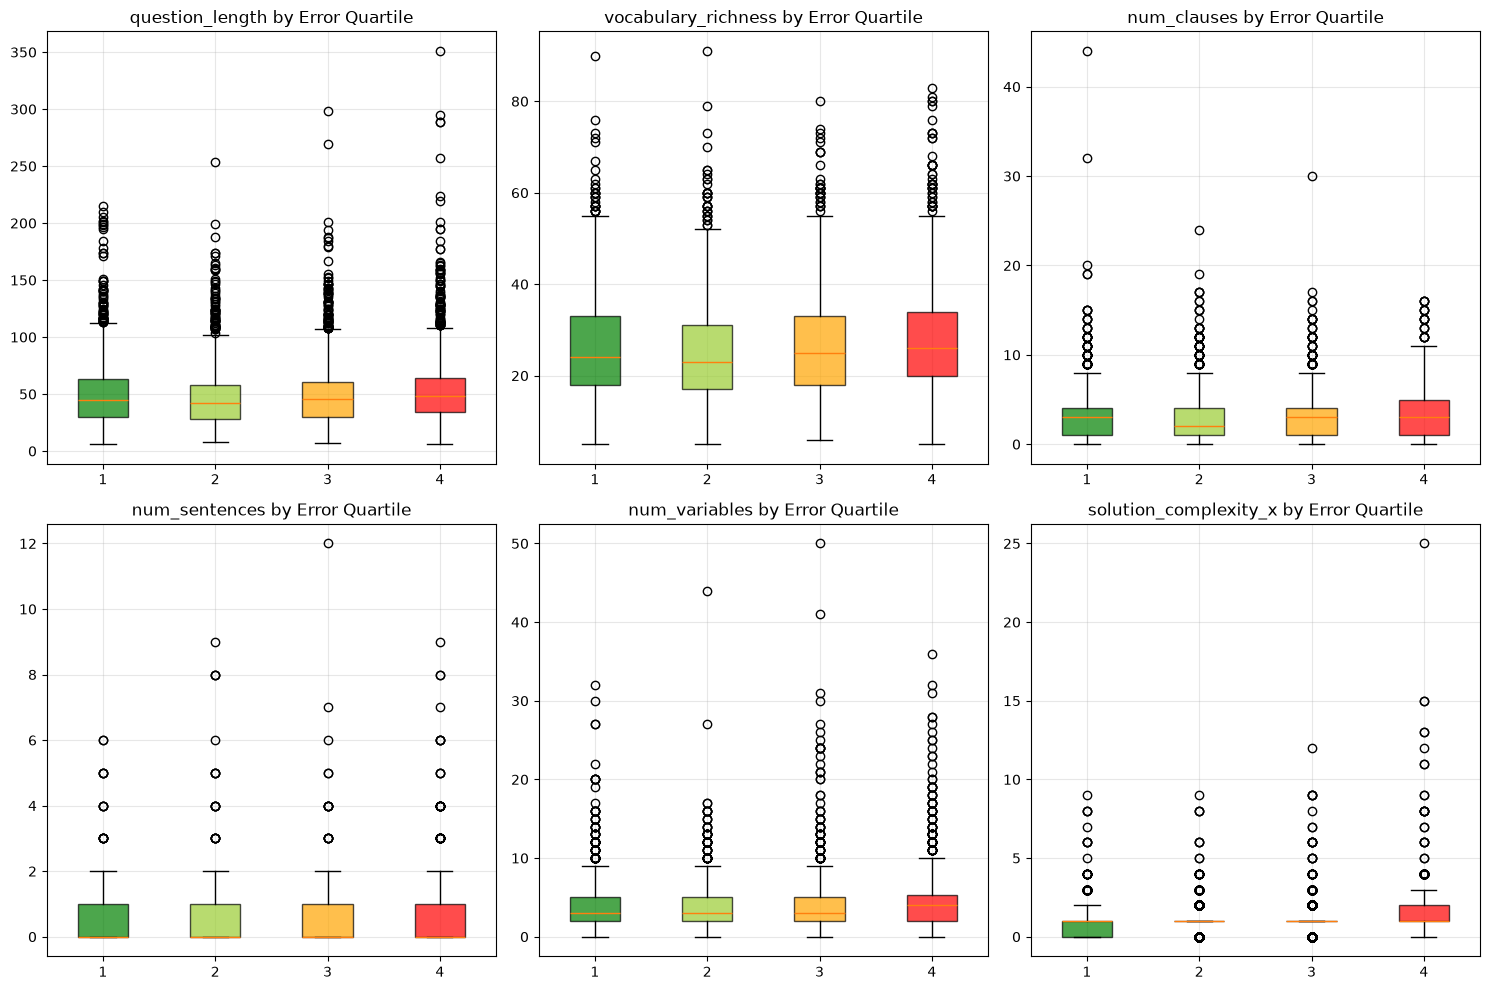

In [5]:
text_metadata['error_quartile'] = pd.qcut(text_metadata['error_rate'], q=4, labels=['Q1 (Low)', 'Q2', 'Q3', 'Q4 (High)'])

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
features_to_plot = ['question_length', 'vocabulary_richness', 'num_clauses', 'num_sentences', 'num_variables', 'solution_complexity_x']

for idx, feature in enumerate(features_to_plot):
    ax = axes[idx // 3, idx % 3]
    data = [text_metadata[text_metadata['error_quartile'] == q][feature].dropna() for q in ['Q1 (Low)', 'Q2', 'Q3', 'Q4 (High)']]
    bp = ax.boxplot(data, patch_artist=True)
    
    # Color boxes
    for patch, color in zip(bp['boxes'], ['green', 'yellowgreen', 'orange', 'red']):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    
    ax.set_title(f'{feature} by Error Quartile')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
#plt.savefig('textual_features_by_error_quartile.png', dpi=300, bbox_inches='tight')
plt.show()

In [8]:
high_error_q_ids = high_error['question_id'].tolist()

# Normalize question embedding keys to strings because the JSON file stores them that way.
normalized_q_embeddings = {str(k): v for k, v in q_embeddings.items()}


def _get_embedding(q_id, embeddings_dict):
    """Return an embedding for a question ID regardless of whether it is stored as int or str."""
    candidates = [q_id, str(q_id)]
    try:
        candidates.append(int(q_id))
    except (TypeError, ValueError):
        pass

    for candidate in candidates:
        if candidate in embeddings_dict:
            return embeddings_dict[candidate]
    return None


# Compute pairwise similarity between high-error questions
def compute_high_error_similarity(q_ids, embeddings_dict, sample_size=1000):
    """Compute average similarity among high-error questions."""
    if len(q_ids) < 2:
        return np.nan

    # Sample if too many (computational)
    if len(q_ids) > sample_size:
        q_ids = np.random.choice(q_ids, sample_size, replace=False).tolist()

    valid_embeddings = []
    for q_id in q_ids:
        embedding = _get_embedding(q_id, embeddings_dict)
        if embedding is not None:
            valid_embeddings.append(embedding)

    if len(valid_embeddings) < 2:
        return np.nan

    q_embeddings_arr = np.array(valid_embeddings)

    # Compute cosine similarity matrix
    sim_matrix = cosine_similarity(q_embeddings_arr)

    # Get upper triangle (excluding diagonal)
    upper_tri = np.triu_indices_from(sim_matrix, k=1)
    avg_sim = sim_matrix[upper_tri].mean()

    return avg_sim

# Baseline: Random questions
random_q_ids = np.random.choice(q_metadata['question_id'].tolist(), len(high_error_q_ids), replace=False).tolist()

high_error_sim = compute_high_error_similarity(high_error_q_ids, normalized_q_embeddings)
random_sim = compute_high_error_similarity(random_q_ids, normalized_q_embeddings)

print(f"\n=== Semantic Similarity of High-Error Questions ===")
print(f"High-error questions similarity: {high_error_sim:.4f}")
print(f"Random questions similarity: {random_sim:.4f}")

if high_error_sim > random_sim:
    print(f" High-error questions are {high_error_sim - random_sim:.3f} more similar than random")
else:
    print("High-error questions are NOT more similar than random")

# ============================================================
# Step 5: Check if high-error questions share linguistic features
# ============================================================

# Check if high-error questions are more likely to:
# - Have images
# - Have multiple methods
# - Have multiple solutions

print("\n=== Categorical Feature Comparison ===")
categorical_features = ['relies_on_image', 'has_multiple_methods']

for feature in categorical_features:
    high_pct = high_error[feature].mean() * 100
    all_pct = all_questions[feature].mean() * 100

    # Chi-square test

    contingency = pd.crosstab(text_metadata[feature], text_metadata['error_rate'] > min_error)
    chi2, p_val, dof, expected = chi2_contingency(contingency)
    print(f"{feature}:")
    print(f"  High-error questions: {high_pct:.1f}%")
    print(f"  All questions: {all_pct:.1f}%")
    print(f"  Chi-square p-value: {p_val:.4f}")


=== Semantic Similarity of High-Error Questions ===
High-error questions similarity: 0.6893
Random questions similarity: 0.6783
 High-error questions are 0.011 more similar than random

=== Categorical Feature Comparison ===
relies_on_image:
  High-error questions: 33.4%
  All questions: 28.2%
  Chi-square p-value: 0.0000
has_multiple_methods:
  High-error questions: 3.3%
  All questions: 2.5%
  Chi-square p-value: 0.0355
